# Predicción de diagnóstico de cáncer

Notebook para construir y evaluar un pipeline de Machine Learning y Red Neuronal Multicapa (MLP) aplicado a la predicción de cáncer. El análisis está planteado como un estudio de viabilidad: no basta con obtener métricas altas, también hay que evitar fuga de datos y justificar que las variables usadas existirían antes del diagnóstico.

## Fases del proyecto

| Fase | Nombre | Objetivo | Qué se hace | Output esperado |
|---|---|---|---|---|
| 0 | Acceso, carga y copia local de datos | Obtener el dataset completo | Conexión a Azure SQL, carga de las 6 tablas, unión por `paciente_id` y exportación a `data/` | `dfs`, `df_cancer` y CSV locales |
| 1 | Preparación para modelado | Dejar los datos listos sin fuga de datos | Separar `X` e `y`, excluir ID y variables post-diagnóstico, split estratificado 80/20 y preprocesamiento ajustado solo en train | `X_train`, `X_test`, `y_train`, `y_test`, `preprocessor` |
| 2 | Modelos ML baseline | Crear una referencia sólida | Entrenar modelos clásicos, comparar métricas en test y revisar importancia de variables | `resultados_ml`, `mejor_modelo_ml`, `feature_importance` |
| 3 | Diseño de la MLP | Definir la arquitectura evaluable | MLP con input igual al número de features, 3 o más capas ocultas, ReLU, Sigmoid, BatchNormalization, Dropout y `class_weight` | Modelo MLP definido |
| 4 | Entrenamiento de la MLP | Entrenar evitando overfitting | Validación interna, EarlyStopping, ReduceLROnPlateau y seguimiento de loss/accuracy | Modelo entrenado e historial |
| 5 | Ajuste del umbral | Optimizar la clasificación de cáncer | Barrer umbrales en validación, elegir el que maximiza F1 y aplicarlo una sola vez en test | Umbral óptimo y predicciones finales |
| 6 | Evaluación final | Comparar modelos correctamente | Calcular precisión, recall, F1 y AUC-ROC en test para el mejor ML y la MLP | Métricas finales |
| 7 | Comparación ML vs MLP | Decidir que modelo gana | Comparar métricas, precisión-recall, robustez, overfitting, interpretabilidad y utilidad clínica | Ranking y conclusión técnica |


# Fase 0 - Acceso, carga y exportación local de datos

En esta fase se accede a la base de datos de Azure SQL, se identifican las tablas del esquema `CASOCANCER`, se cargan las seis colecciones del caso, se unen por `paciente_id` y se guardan copias locales en la carpeta `data/`.

El resultado principal de esta fase es `df_cancer`, el dataset completo unido, con 50.001 pacientes y 38 columnas.


In [2]:
# Acceso a los datos del caso desde Azure SQL
import struct
import urllib.parse

import pandas as pd
from azure.identity import DeviceCodeCredential
from sqlalchemy import create_engine, event, text
from sqlalchemy.exc import OperationalError

# Configuración de conexión
SERVER = "tcp:uaxmathfis.database.windows.net,1433"
DATABASE = "usecases"
DRIVER = "{ODBC Driver 18 for SQL Server}"
SQL_COPT_SS_ACCESS_TOKEN = 1256
TOKEN_SCOPE = "https://database.windows.net/.default"

params = urllib.parse.quote_plus(
    f"DRIVER={DRIVER};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    "Encrypt=yes;"
    "TrustServerCertificate=no;"
    "Connection Timeout=60;"
)

# En notebooks, el login por código de dispositivo es mas estable que ActiveDirectoryInteractive.
# Al ejecutar la celda, copia el codigo que aparezca y completa el login en la URL indicada.
credential = DeviceCodeCredential()

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}",
    pool_pre_ping=True,
)

@event.listens_for(engine, "do_connect")
def provide_azure_ad_token(dialect, conn_rec, cargs, cparams):
    token = credential.get_token(TOKEN_SCOPE).token.encode("utf-16-le")
    token_struct = struct.pack(f"<I{len(token)}s", len(token), token)
    cparams["attrs_before"] = {SQL_COPT_SS_ACCESS_TOKEN: token_struct}

# Prueba de conexión y listado de tablas disponibles
try:
    with engine.connect() as conn:
        print("Conexión establecida correctamente")
        tablas = pd.read_sql(
            text("""
            SELECT TABLE_SCHEMA, TABLE_NAME
            FROM INFORMATION_SCHEMA.TABLES
            WHERE TABLE_TYPE = 'BASE TABLE'
            ORDER BY TABLE_SCHEMA, TABLE_NAME
            """),
            conn,
        )
except OperationalError as exc:
    print("No se pudo conectar a Azure SQL.")
    print("Comprueba que aparece la ventana de login MFA, que tienes red/VPN si aplica y que tu usuario tiene acceso a la base de datos.")
    raise exc

tablas


To sign in, use a web browser to open the page https://login.microsoft.com/device and enter the code CN9XLZTBG to authenticate.
Conexión establecida correctamente


,TABLE_SCHEMA,TABLE_NAME
0,CASOCANCER,CASOCANCER_01_BIOQUIMICOS
1,CASOCANCER,CASOCANCER_02_CLINICOS
2,CASOCANCER,CASOCANCER_03_GENETICOS
3,CASOCANCER,CASOCANCER_04_ECONOMICOS
4,CASOCANCER,CASOCANCER_05_GENERALES
5,CASOCANCER,CASOCANCER_06_SOCIODEMOGRAFICOS
6,CASOMAT_MMM,CASOMAT_MM_01_CLIENTES
7,CASOMAT_MMM,CASOMAT_MM_02_PRODUCTOS
8,CASOMAT_MMM,CASOMAT_MM_03_CALENDARIO
9,CASOMAT_MMM,CASOMAT_MM_04_TRAFICO_DIARIO


In [3]:
# Carga de las seis tablas del caso cáncer y unión por paciente_id
from functools import reduce

tablas_cancer = {
    "bioquimicos": "CASOCANCER.CASOCANCER_01_BIOQUIMICOS",
    "clinicos": "CASOCANCER.CASOCANCER_02_CLINICOS",
    "geneticos": "CASOCANCER.CASOCANCER_03_GENETICOS",
    "economicos": "CASOCANCER.CASOCANCER_04_ECONOMICOS",
    "generales": "CASOCANCER.CASOCANCER_05_GENERALES",
    "sociodemograficos": "CASOCANCER.CASOCANCER_06_SOCIODEMOGRAFICOS",
}

dfs = {}

with engine.connect() as conn:
    for nombre, tabla_sql in tablas_cancer.items():
        query = text(f"SELECT * FROM {tabla_sql}")
        dfs[nombre] = pd.read_sql(query, conn)
        print(f"{nombre:18s} -> {dfs[nombre].shape[0]:6d} filas x {dfs[nombre].shape[1]:3d} columnas")

# Comprobación básica de clave
for nombre, df in dfs.items():
    if "paciente_id" not in df.columns:
        raise ValueError(f"La tabla {nombre} no contiene la columna paciente_id")
    duplicados = df["paciente_id"].duplicated().sum()
    if duplicados > 0:
        print(f"Aviso: {nombre} contiene {duplicados} paciente_id duplicados")

# Unión final. validate='one_to_one' detecta problemas de duplicados en la clave.
df_cancer = reduce(
    lambda izq, der: izq.merge(der, on="paciente_id", how="inner", validate="one_to_one"),
    dfs.values(),
)

print(f"\nDataset unido -> {df_cancer.shape[0]} filas x {df_cancer.shape[1]} columnas")
df_cancer.head()


bioquimicos        ->  50001 filas x   8 columnas
clinicos           ->  50001 filas x   8 columnas
geneticos          ->  50001 filas x   8 columnas
economicos         ->  50001 filas x   6 columnas
generales          ->  50001 filas x   5 columnas
sociodemograficos  ->  50001 filas x   8 columnas

Dataset unido -> 50001 filas x 38 columnas


,paciente_id,glucosa,colesterol,trigliceridos,hemoglobina,leucocitos,plaquetas,creatinina,diabetes,hipertension,...,alcohol,actividad_fisica,vive,edad,nivel_educativo,nivel_ingresos,zona,estado_civil,num_hijos,distancia_hospital_km
0,P1000000,94.66,205.32,130.31,16.62,10.08,252.46,0.84,0,0,...,1,Moderada,1,53,Secundaria,Medio,Urbana,Casado,2,25.6
1,P1000001,103.94,235.17,149.65,13.09,7.21,171.32,0.81,0,0,...,1,Moderada,1,66,Secundaria,Alto,Urbana,Divorciado,0,15.2
2,P1000002,131.34,138.42,166.95,15.32,6.15,331.48,0.93,1,1,...,1,Moderada,1,33,Secundaria,Bajo,Urbana,Casado,3,43.7
3,P1000003,115.03,182.81,132.24,14.58,4.39,349.31,1.09,1,1,...,1,Baja,1,45,Secundaria,Bajo,Urbana,Viudo,3,0.5
4,P1000004,103.97,237.70,134.30,14.44,6.11,190.03,1.20,0,0,...,1,Baja,1,53,Secundaria,Bajo,Urbana,Casado,0,7.3


In [4]:
# Exportación local de las tablas originales y del dataset unido
from pathlib import Path

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

for nombre, df in dfs.items():
    ruta = data_dir / f"{nombre}.csv"
    df.to_csv(ruta, index=False)
    print(f"Guardado {ruta} -> {df.shape[0]} filas x {df.shape[1]} columnas")

ruta_unido = data_dir / "cancer_dataset_unido.csv"
df_cancer.to_csv(ruta_unido, index=False)
print(f"\nGuardado {ruta_unido} -> {df_cancer.shape[0]} filas x {df_cancer.shape[1]} columnas")


Guardado data/bioquimicos.csv -> 50001 filas x 8 columnas
Guardado data/clinicos.csv -> 50001 filas x 8 columnas
Guardado data/geneticos.csv -> 50001 filas x 8 columnas
Guardado data/economicos.csv -> 50001 filas x 6 columnas
Guardado data/generales.csv -> 50001 filas x 5 columnas
Guardado data/sociodemograficos.csv -> 50001 filas x 8 columnas

Guardado data/cancer_dataset_unido.csv -> 50001 filas x 38 columnas


# Fase 1 - Preparación para modelado

En esta fase se parte del CSV local `data/cancer_dataset_unido.csv`, se separa la variable objetivo `cancer`, se excluye el identificador `paciente_id`, se realiza un split estratificado 80/20 y se define el preprocesamiento para modelos.

La decisión más importante de esta fase es evitar **data leakage** y retirar variables no informativas. Por eso se excluyen `coste_total`, `coste_farmaco`, `num_ingresos`, `dias_hospital` y `vive`: son variables que pueden ser consecuencia del diagnóstico, del tratamiento o de la evolución posterior del paciente. También se excluye `alcohol`, porque el metadata actualizado indica que es constante. Si se mantuvieran, el modelo podría aparentar un rendimiento excelente o añadir ruido sin resolver realmente un problema de predicción previa.

| Paso | Acción | Resultado |
|---|---|---|
| 1 | Cargar dataset local | `df_cancer` |
| 2 | Separar features y target | `X`, `y` |
| 3 | Excluir ID y variables con posible fuga | `excluded_features` |
| 4 | Dividir train/test estratificado | `X_train`, `X_test`, `y_train`, `y_test` |
| 5 | Ajustar transformaciones solo en train | `preprocessor`, `X_train_prep`, `X_test_prep` |
| 6 | Comprobar balance de clases | Tabla de prevalencia en total/train/test |


In [5]:
# Fase 1 - Preparacion para modelado
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TARGET = "cancer"
ID_COL = "paciente_id"

# Variables excluidas para evitar fuga de datos.
# Son variables potencialmente posteriores al diagnóstico/tratamiento, no datos limpios de cribado.
leakage_or_postdiagnosis_features = [
    "coste_total",
    "coste_farmaco",
    "num_ingresos",
    "dias_hospital",
    "vive",
    "alcohol",
]

# Cargamos desde local para no depender de Azure SQL en las siguientes fases
df_cancer = pd.read_csv("data/cancer_dataset_unido.csv")

# Separación X/y. El identificador y las variables post-diagnóstico o no informativas no se usan como predictores.
excluded_features = [TARGET, ID_COL] + leakage_or_postdiagnosis_features
X = df_cancer.drop(columns=excluded_features)
y = df_cancer[TARGET].astype(int)

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

# StandardScaler se ajusta solo con train. OneHotEncoder gestiona categorias no vistas en test.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print(f"Dataset completo: {df_cancer.shape[0]} filas x {df_cancer.shape[1]} columnas")
print(f"Features usadas: {X.shape[1]}")
print(f"Features excluidas: {excluded_features}")
print(f"Features tras preprocesamiento: {X_train_prep.shape[1]}")
print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"Columnas numéricas: {len(numeric_features)}")
print(f"Columnas categóricas: {len(categorical_features)} -> {categorical_features}")

balance = pd.DataFrame(
    {
        "dataset": ["total", "train", "test"],
        "n": [len(y), len(y_train), len(y_test)],
        "positivos_cancer": [int(y.sum()), int(y_train.sum()), int(y_test.sum())],
        "prevalencia_cancer": [y.mean(), y_train.mean(), y_test.mean()],
    }
)

balance


Dataset completo: 50001 filas x 38 columnas
Features usadas: 30
Features excluidas: ['cancer', 'paciente_id', 'coste_total', 'coste_farmaco', 'num_ingresos', 'dias_hospital', 'vive', 'alcohol']
Features tras preprocesamiento: 45
Train: 40000 filas | Test: 10001 filas
Columnas numéricas: 24
Columnas categóricas: 6 -> ['tipo_seguro', 'actividad_fisica', 'nivel_educativo', 'nivel_ingresos', 'zona', 'estado_civil']


,dataset,n,positivos_cancer,prevalencia_cancer
0,total,50001,9644,0.192876
1,train,40000,7715,0.192875
2,test,10001,1929,0.192881


# Fase 2 - Modelos de Machine Learning baseline

En esta fase se entrenan varios modelos clásicos para construir una referencia sólida antes de la red neuronal. La comparación se centra en la clase positiva `cancer = 1`, por lo que las métricas principales son precisión, recall, F1-score y AUC-ROC. La accuracy se muestra solo como apoyo, porque el dataset está desbalanceado.

| Modelo | Motivo de uso |
|---|---|
| Logistic Regression | Baseline lineal, rápido e interpretable |
| Random Forest | Ensemble robusto de árboles, útil para relaciones no lineales |
| HistGradientBoosting | Boosting eficiente en datos tabulares; suele capturar interacciones complejas |
| Extra Trees | Ensemble muy aleatorizado; útil como comparador y para importancia de variables |

El modelo ganador se escoge por `f1_cancer_1` y `auc_roc`, no por accuracy. Además, los resultados deben interpretarse junto con la revisión de variables importantes: métricas muy altas pueden indicar fuga de datos si aparecen variables posteriores al diagnóstico.

Output esperado: tabla comparativa `resultados_ml`, variable `mejor_modelo_ml` y matriz de confusion del mejor baseline.


In [6]:
# Fase 2 - Entrenamiento y evaluación de modelos ML baseline
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

modelos_ml = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.06,
        l2_regularization=0.1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

def probabilidades_clase_positiva(modelo, X):
    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(X)[:, 1]
    if hasattr(modelo, "decision_function"):
        scores = modelo.decision_function(X)
        return 1 / (1 + np.exp(-scores))
    raise TypeError(f"El modelo {type(modelo).__name__} no devuelve probabilidades ni scores")

filas_resultados = []
modelos_entrenados = {}

for nombre, modelo in modelos_ml.items():
    print(f"Entrenando {nombre}...")
    modelo.fit(X_train_prep, y_train)
    modelos_entrenados[nombre] = modelo

    y_proba = probabilidades_clase_positiva(modelo, X_test_prep)
    y_pred = (y_proba >= 0.50).astype(int)

    filas_resultados.append(
        {
            "modelo": nombre,
            "precision_cancer_1": precision_score(y_test, y_pred, zero_division=0),
            "recall_cancer_1": recall_score(y_test, y_pred, zero_division=0),
            "f1_cancer_1": f1_score(y_test, y_pred, zero_division=0),
            "auc_roc": roc_auc_score(y_test, y_proba),
            "accuracy": accuracy_score(y_test, y_pred),
        }
    )

resultados_ml = (
    pd.DataFrame(filas_resultados)
    .sort_values(["f1_cancer_1", "auc_roc"], ascending=False)
    .reset_index(drop=True)
)

mejor_modelo_ml_nombre = resultados_ml.loc[0, "modelo"]
mejor_modelo_ml = modelos_entrenados[mejor_modelo_ml_nombre]

print(f"\nMejor modelo ML baseline según F1: {mejor_modelo_ml_nombre}")
resultados_ml


Entrenando Logistic Regression...
Entrenando Random Forest...
Entrenando HistGradientBoosting...
Entrenando Extra Trees...

Mejor modelo ML baseline según F1: HistGradientBoosting


,modelo,precision_cancer_1,recall_cancer_1,f1_cancer_1,auc_roc,accuracy
0,HistGradientBoosting,0.440909,0.754277,0.556512,0.843218,0.768123
1,Logistic Regression,0.434938,0.758942,0.552975,0.841417,0.763324
2,Extra Trees,0.576877,0.501814,0.536734,0.830999,0.832917
3,Random Forest,0.676043,0.361327,0.470946,0.835378,0.843416


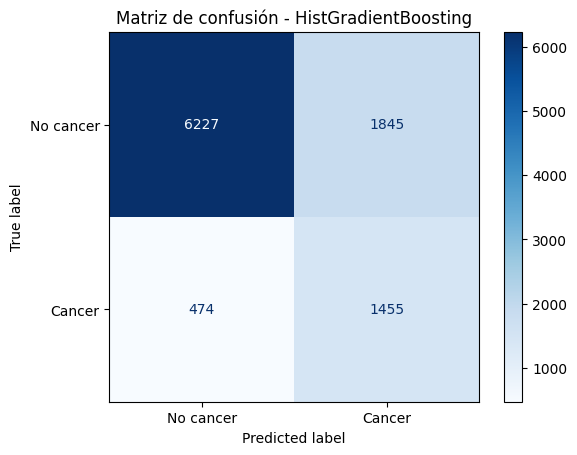

array([[6227, 1845],
       [ 474, 1455]])

In [7]:
# Matriz de confusión del mejor modelo ML baseline
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_proba_mejor_ml = probabilidades_clase_positiva(mejor_modelo_ml, X_test_prep)
y_pred_mejor_ml = (y_proba_mejor_ml >= 0.50).astype(int)

matriz_confusion_ml = confusion_matrix(y_test, y_pred_mejor_ml)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_ml,
    display_labels=["No cancer", "Cancer"],
)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusión - {mejor_modelo_ml_nombre}")
plt.show()

matriz_confusion_ml


## Feature importance

Esta seccion calcula la importancia de variables para interpretar que esta aprendiendo el baseline de Machine Learning. La interpretación es especialmente importante en este caso porque antes detectamos variables con fuga de datos: si `coste_total`, `dias_hospital`, `coste_farmaco`, `num_ingresos` o `vive` aparecieran en el ranking, el resultado no seria valido para un escenario de predicción previa.

`HistGradientBoosting` puede ser el mejor modelo por F1, pero en scikit-learn no expone `feature_importances_` de forma nativa. Por eso, para la gráfica se usa el mejor modelo entrenado que si tenga importancias nativas, normalmente `Extra Trees` o `Random Forest`. Esto no cambia la comparativa de rendimiento: solo se usa un modelo de árboles como herramienta de interpretación.

Las columnas categóricas generadas por `OneHotEncoder` se agrupan de nuevo por variable original. Asi, por ejemplo, todas las columnas derivadas de `nivel_ingresos` se resumen en una unica importancia agregada.


HistGradientBoosting no expone feature_importances_. Se usa Extra Trees para interpretar variables.


,feature_original,importance
0,fumador,0.085637
1,tipo_seguro,0.065563
2,obesidad,0.062714
3,nivel_ingresos,0.060461
4,mut_BRCA1,0.059911
5,nivel_educativo,0.059371
6,estado_civil,0.057132
7,mut_TP53,0.054135
8,zona,0.046410
9,actividad_fisica,0.043245


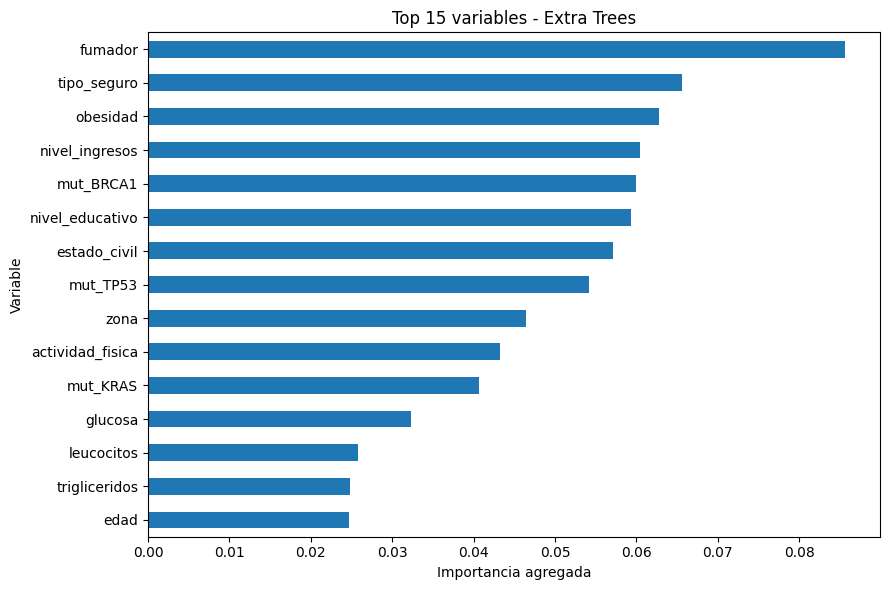

In [8]:
# Feature importance del mejor modelo ML baseline
import matplotlib.pyplot as plt
import pandas as pd

modelo_importancia_nombre = mejor_modelo_ml_nombre
modelo_importancia = mejor_modelo_ml

if not hasattr(modelo_importancia, "feature_importances_"):
    candidatos_importancia = [
        nombre
        for nombre in resultados_ml["modelo"]
        if hasattr(modelos_entrenados[nombre], "feature_importances_")
    ]
    if not candidatos_importancia:
        raise TypeError("Ningun modelo entrenado expone feature_importances_.")
    modelo_importancia_nombre = candidatos_importancia[0]
    modelo_importancia = modelos_entrenados[modelo_importancia_nombre]
    print(
        f"{mejor_modelo_ml_nombre} no expone feature_importances_. "
        f"Se usa {modelo_importancia_nombre} para interpretar variables."
    )

importancias = pd.DataFrame(
    {
        "feature_preprocesada": feature_names,
        "importance": modelo_importancia.feature_importances_,
    }
)

def variable_original(feature_name):
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "")
    if feature_name.startswith("cat__"):
        nombre = feature_name.replace("cat__", "")
        for col in categorical_features:
            if nombre == col or nombre.startswith(f"{col}_"):
                return col
        return nombre
    return feature_name

importancias["feature_original"] = importancias["feature_preprocesada"].apply(variable_original)

feature_importance = (
    importancias.groupby("feature_original", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

variables_con_fuga_en_importancia = sorted(
    set(feature_importance["feature_original"]).intersection(leakage_or_postdiagnosis_features)
)
if variables_con_fuga_en_importancia:
    raise ValueError(
        "La feature importance contiene variables excluidas por posible fuga de datos: "
        f"{variables_con_fuga_en_importancia}. Reinicia el kernel y ejecuta de nuevo Fase 1 y Fase 2."
    )

top_n = 15
top_importance = feature_importance.head(top_n).sort_values("importance")

display(feature_importance.head(top_n))

ax = top_importance.plot.barh(
    x="feature_original",
    y="importance",
    figsize=(9, 6),
    legend=False,
)
ax.set_title(f"Top {top_n} variables - {modelo_importancia_nombre}")
ax.set_xlabel("Importancia agregada")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()


## Interpretación de la feature importance

La gráfica muestra que variables pesan más en el modelo usado para interpretar (`Extra Trees` o `Random Forest`). No mide causalidad: solo asociación predictiva.

Se usa un modelo de árboles porque expone `feature_importances_` de forma nativa. Si el mejor modelo por métricas es `HistGradientBoosting`, se mantiene como baseline ganador, pero se usa el árbol para explicar variables.

Puntos clave:

- No deben aparecer variables post-diagnóstico como costes, ingresos hospitalarios o `vive`.
- Variables clínicas o de estilo de vida son plausibles para cribado.
- Variables genéticas y socioeconómicas pueden ser útiles, pero requieren cautela ética y justificación.


# Fase 3 - Diseño de la Red Neuronal MLP

En esta fase se define la arquitectura de la red neuronal multicapa. La entrada es el número de variables tras el preprocesamiento (`X_train_prep.shape[1]`) y la salida es una neurona con activación `sigmoid`, porque el problema es binario: `cancer = 0/1`.

La arquitectura se mantiene deliberadamente contenida porque el problema es tabular: hay 45 features tras el preprocesamiento y una red demásiado grande puede sobreajustar. Se usan 3 capas ocultas para cumplir el enunciado, pero con menos neuronas que una arquitectura profunda pesada.

| Elemento | Decisión | Justificacion |
|---|---|---|
| Entrada | `input_dim = X_train_prep.shape[1]` | Usa exactamente las features preprocesadas |
| Capas ocultas | 128, 64 y 32 neuronas | 3 capas ocultas, pero tamaño razonable para tabular |
| Activacion | ReLU | Adecuada para relaciones no lineales |
| Regularización | BatchNormalization + Dropout + L2 | Reduce inestabilidad y sobreajuste |
| Dropout | 0.25, 0.25, 0.20 | Exigido por el enunciado; aparece con 0 parámetros porque no aprende pesos |
| Salida | 1 neurona Sigmoid | Devuelve probabilidad de cáncer |
| Desbalance | `class_weight` | Penaliza más los errores sobre la clase minoritaria |

Nota: en el `summary`, las capas Dropout aparecen con `Param # = 0`. Eso es normal: Dropout no tiene parámetros entrenables; solo desactiva neuronas aleatoriamente durante el entrenamiento.

El entorno actual usa Python 3.14. TensorFlow no está disponible para esta versión, por lo que la MLP se define con **Keras 3 usando backend Torch**. La API de Keras se mantiene y el modelo sigue siendo una MLP con capas densas, BatchNormalization y Dropout.


In [9]:
# Fase 3 - Definición de la arquitectura MLP con Keras
import os

# Keras 3 necesita elegir backend antes de importarse. En Python 3.14 usamos Torch.
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import keras

from keras import layers, regularizers
from sklearn.utils.class_weight import compute_class_weight

keras.utils.set_random_seed(RANDOM_STATE)

input_dim = X_train_prep.shape[1]

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train,
)
class_weight = {0: float(class_weights_array[0]), 1: float(class_weights_array[1])}

def crear_modelo_mlp(input_dim):
    modelo = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Dropout(0.25),
            layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Dropout(0.25),
            layers.Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Dropout(0.20),
            layers.Dense(1, activation="sigmoid"),
        ]
    )

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return modelo

mlp_model = crear_modelo_mlp(input_dim)

print(f"Backend Keras: {keras.backend.backend()}")
print(f"Input dim: {input_dim}")
print(f"Class weight: {class_weight}")
mlp_model.summary()


Backend Keras: torch
Input dim: 46
Class weight: {0: 0.6194827319188477, 1: 2.592352559948153}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,281 (67.50 KB)

 Trainable params: 16,833 (65.75 KB)

 Non-trainable params: 448 (1.75 KB)

# Fase 4 - Entrenamiento de la MLP

En esta fase se entrena la red neuronal controlando el sobreajuste. Se crea una validación interna estratificada a partir del conjunto de train. Esa misma validación se reutilizará en la Fase 5 para ajustar el umbral sin tocar test.

| Elemento | Decisión | Motivo |
|---|---|---|
| Split interno | 80% train interno / 20% validación | Permite monitorizar generalización y ajustar umbral |
| `EarlyStopping` | paciencia 12 | Detiene si la pérdida de validación deja de mejorar |
| `ReduceLROnPlateau` | paciencia 6, factor 0.5 | Reduce learning rate si la validación se estanca |
| `class_weight` | calculado en Fase 3 | Compensa el desbalance de `cancer = 1` |
| Curvas | loss y accuracy train/val | Detectan overfitting |

Señal de overfitting: si `loss` de train sigue bajando pero `val_loss` sube, la red esta memorizando patrones del train.


Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7790 - auc: 0.7236 - loss: 0.5008 - precision: 0.4219 - recall: 0.3936 - val_accuracy: 0.8257 - val_auc: 0.8181 - val_loss: 0.4366 - val_precision: 0.5553 - val_recall: 0.4848 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8258 - auc: 0.7977 - loss: 0.4206 - precision: 0.5773 - recall: 0.3624 - val_accuracy: 0.8335 - val_auc: 0.8285 - val_loss: 0.3976 - val_precision: 0.5815 - val_recall: 0.4880 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8280 - auc: 0.8106 - loss: 0.4090 - precision: 0.5874 - recall: 0.3642 - val_accuracy: 0.8346 - val_auc: 0.8309 - val_loss: 0.3931 - val_precision: 0.5842 - val_recall: 0.4945 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8336 - auc: 0.8186 - loss: 0.4014 - precision: 0.6115 - recall: 0.3767 - val_accuracy: 0.8374 - val_auc: 0.8316 - val_loss: 0.39

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
28,0.845906,0.853696,0.361533,0.675035,0.387719,0.844750,0.833362,0.376706,0.679809,0.368762,0.0005
29,0.848250,0.854038,0.361293,0.688000,0.390149,0.844750,0.832309,0.377159,0.676023,0.374595,0.0005
30,0.847750,0.855837,0.358446,0.681869,0.394848,0.844875,0.832664,0.377363,0.675581,0.376539,0.0005
31,0.846187,0.856432,0.358871,0.677255,0.386909,0.844875,0.832155,0.377523,0.688279,0.357745,0.0005
32,0.848031,0.856272,0.358110,0.681654,0.397926,0.844125,0.831826,0.378008,0.680488,0.361633,0.0005


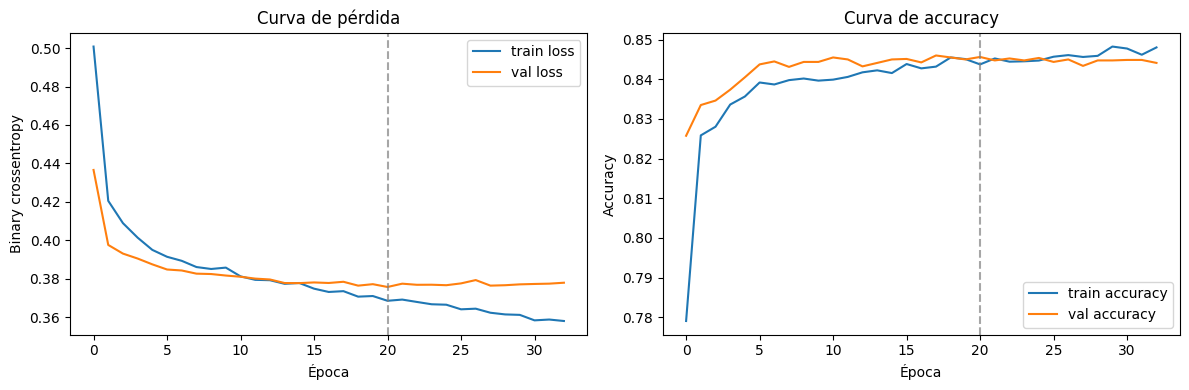

In [10]:
# Fase 4 - Entrenamiento de la MLP con validación y callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

X_train_mlp = X_train_prep.astype("float32")
y_train_mlp = y_train.to_numpy().astype("float32")

X_mlp_train, X_mlp_val, y_mlp_train, y_mlp_val = train_test_split(
    X_train_mlp,
    y_train_mlp,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=1e-5,
    verbose=1,
)

history_mlp = mlp_model.fit(
    X_mlp_train,
    y_mlp_train,
    validation_data=(X_mlp_val, y_mlp_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

history_df = pd.DataFrame(history_mlp.history)
mejor_época = int(history_df["val_loss"].idxmin() + 1)
print(f"Mejor época segun val_loss: {mejor_época}")
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["loss"], label="train loss")
axes[0].plot(history_df["val_loss"], label="val loss")
axes[0].axvline(mejor_época - 1, color="gray", linestyle="--", alpha=0.7)
axes[0].set_title("Curva de pérdida")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Binary crossentropy")
axes[0].legend()

axes[1].plot(history_df["accuracy"], label="train accuracy")
axes[1].plot(history_df["val_accuracy"], label="val accuracy")
axes[1].axvline(mejor_época - 1, color="gray", linestyle="--", alpha=0.7)
axes[1].set_title("Curva de accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## Como leer las curvas de entrenamiento

- Si `loss` y `val_loss` bajan juntas, el entrenamiento es estable.
- Si `loss` baja pero `val_loss` sube, hay sobreajuste.
- Si EarlyStopping se activa, se recuperan los pesos de la mejor época de validación.
- La métrica final no se decide aquí: se evaluará después sobre test y con el umbral ajustado en validación.


# Fase 5 - Ajuste del umbral de clasificación

Tanto los modelos clásicos como la MLP devuelven probabilidades, no clases definitivas. Usar directamente `threshold = 0.5` puede ser inadecuado en un problema desbalanceado como cáncer, porque el punto de corte cambia el equilibrio entre precisión y recall.

En una primera comparación, la MLP usaba un umbral ajustado en validación, mientras que el baseline clásico se evaluaba con `threshold = 0.5`. Esa comparación era útil como referencia inicial, pero no era completamente simétrica. Por eso se actualiza esta fase para ajustar también el umbral del mejor baseline ML con la misma regla que la MLP.

| Paso | Acción | Motivo |
|---|---|---|
| 1 | Crear train/validación interna | El umbral no debe elegirse con test |
| 2 | Entrenar la MLP con train interno | La validación queda como datos no usados para pesos |
| 3 | Entrenar un clon del mejor baseline en train interno | Permite ajustar su umbral sin usar test |
| 4 | Predecir probabilidades en validación | Permite probar umbrales comparables |
| 5 | Barrer umbrales 0.10 a 0.90 | Buscar el mejor compromiso precisión-recall |
| 6 | Elegir el umbral que maximiza F1 para cada modelo | Misma métrica de selección para ambos |
| 7 | Aplicar los umbrales después en test | Evita data leakage |

Importante: el conjunto de test no se usa para elegir ningún umbral. Solo se usa en la evaluación final.


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Umbral óptimo HistGradientBoosting: 0.65
Umbral óptimo MLP: 0.32


,modelo,threshold,precision,recall,f1
0,HistGradientBoosting,0.65,0.560,0.591,0.575
1,MLP,0.32,0.524,0.620,0.568


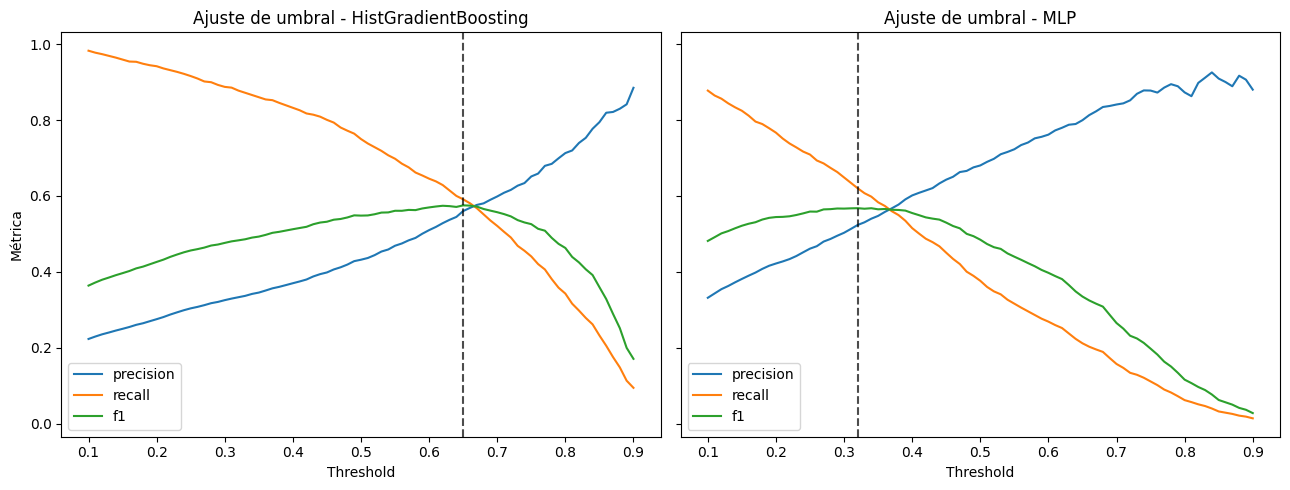

In [11]:
# Fase 5 - Búsqueda del umbral óptimo en validación
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import f1_score, precision_score, recall_score

# Usamos la validación interna creada en Fase 4. No se toca el conjunto de test.
thresholds = np.arange(0.10, 0.91, 0.01)


def evaluar_thresholds(y_true, y_proba, nombre_modelo):
    filas = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        filas.append(
            {
                "modelo": nombre_modelo,
                "threshold": threshold,
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    return pd.DataFrame(filas)


# MLP: probabilidades en la validación interna usada durante el entrenamiento.
y_val_proba_mlp = mlp_model.predict(X_mlp_val).ravel()
threshold_results_mlp = evaluar_thresholds(y_mlp_val, y_val_proba_mlp, "MLP")
best_threshold_row_mlp = threshold_results_mlp.sort_values("f1", ascending=False).iloc[0]
best_threshold_mlp = float(best_threshold_row_mlp["threshold"])

# Baseline ML: se clona el mejor modelo y se entrena solo con train interno.
# Así el umbral se elige sobre validación sin haber visto test.
modelo_ml_para_umbral = clone(mejor_modelo_ml)
modelo_ml_para_umbral.fit(X_mlp_train, y_mlp_train.astype(int))
y_val_proba_ml = probabilidades_clase_positiva(modelo_ml_para_umbral, X_mlp_val)
threshold_results_ml = evaluar_thresholds(
    y_mlp_val.astype(int),
    y_val_proba_ml,
    mejor_modelo_ml_nombre,
)
best_threshold_row_ml = threshold_results_ml.sort_values("f1", ascending=False).iloc[0]
best_threshold_ml = float(best_threshold_row_ml["threshold"])

threshold_results = pd.concat(
    [threshold_results_ml, threshold_results_mlp],
    ignore_index=True,
)
best_thresholds = pd.DataFrame(
    [best_threshold_row_ml, best_threshold_row_mlp]
).reset_index(drop=True)

print(f"Umbral óptimo {mejor_modelo_ml_nombre}: {best_threshold_ml:.2f}")
print(f"Umbral óptimo MLP: {best_threshold_mlp:.2f}")

display(
    best_thresholds.style.format(
        {
            "threshold": "{:.2f}",
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1": "{:.3f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, nombre_modelo, best_threshold in [
    (axes[0], mejor_modelo_ml_nombre, best_threshold_ml),
    (axes[1], "MLP", best_threshold_mlp),
]:
    datos_modelo = threshold_results[threshold_results["modelo"] == nombre_modelo]
    datos_modelo.plot(
        x="threshold",
        y=["precision", "recall", "f1"],
        ax=ax,
    )
    ax.axvline(best_threshold, color="black", linestyle="--", alpha=0.7)
    ax.set_title(f"Ajuste de umbral - {nombre_modelo}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Métrica")

plt.tight_layout()
plt.show()


## Interpretación del umbral

- Un umbral menor aumenta recall, pero suele generar más falsos positivos.
- Un umbral mayor aumenta precisión, pero puede perder casos reales de cáncer.
- El umbral elegido maximiza F1 en validación para cada modelo.
- El test queda intacto para la evaluación final.

Para que la comparación sea justa, el baseline clásico y la MLP se ajustan con la misma regla: elegir el umbral que maximiza F1 en una validación interna. En el baseline se usa un clon entrenado solo con train interno para decidir el umbral; la evaluación final sigue haciéndose sobre test con el modelo entrenado en todo el train.

Esto corrige un matiz importante de la comparación inicial: antes la MLP estaba evaluada con un umbral optimizado y el baseline con `0.50`. Al optimizar ambos, la comparación pasa a medir mejor la calidad del modelo y no solo la elección del punto de corte.

Si el F1 máximo queda alrededor de 0.56-0.58, no debe interpretarse como un error de código. Indica que el problema es difícil: los datos tienen ruido, las clases se solapan y, al eliminar variables con fuga, el modelo ya no dispone de señales artificialmente fáciles. La conclusión de viabilidad debería ser prudente: el sistema puede servir como apoyo o priorización, pero no como diagnóstico automático.


## Comparación tras optimizar umbrales

Al aplicar la misma regla de selección de umbral a ambos modelos, el resultado cambia respecto a la comparación inicial.

En la comparación inicial:

- La MLP usaba un umbral optimizado en validación.
- `HistGradientBoosting` usaba el umbral estándar `0.50`.
- La MLP podía aparecer como ganadora por F1, pero la comparación no era totalmente equivalente.

Tras optimizar también el umbral del baseline clásico, la comparación queda más defendible. La tabla generada en la Fase 6/Fase 7 es la fuente de verdad para los valores exactos de cada ejecución.

En las ejecuciones revisadas, `HistGradientBoosting` queda por encima en F1 y AUC-ROC con umbral operativo `0.65`. La MLP puede mantener mayor recall, pero lo hace a costa de más falsos positivos y menor precisión. Además, al reentrenarse como red neuronal puede mostrar pequeñas variaciones en el umbral óptimo y en sus métricas, por lo que no conviene hardcodear sus cifras en la interpretación.

Esto no invalida la MLP. Lo que indica es que su ventaja inicial dependía en parte del ajuste de umbral. Una comparación justa exige optimizar el punto de corte de ambos modelos antes de decidir cuál conviene recomendar.


# Fase 6 - Evaluación final en test

En esta fase se evalúan los modelos sobre el conjunto de test, que no se ha usado ni para entrenar ni para ajustar umbrales. Esta es la comparación final honesta.

| Modelo | Predicción usada | Motivo |
|---|---|---|
| Mejor ML baseline | `best_threshold_ml` elegido en validación | Compara el baseline con la misma regla que la MLP |
| MLP | `best_threshold_mlp` elegido en validación | Evita usar test para optimizar el umbral |

Las métricas principales son precisión, recall, F1-score y AUC-ROC para `cancer = 1`. La accuracy se mantiene solo como referencia secundaria.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,modelo,threshold,precision_cancer_1,recall_cancer_1,f1_cancer_1,auc_roc,accuracy
0,HistGradientBoosting,0.65,0.552,0.602,0.576,0.843,0.829
1,MLP,0.32,0.522,0.630,0.571,0.840,0.817


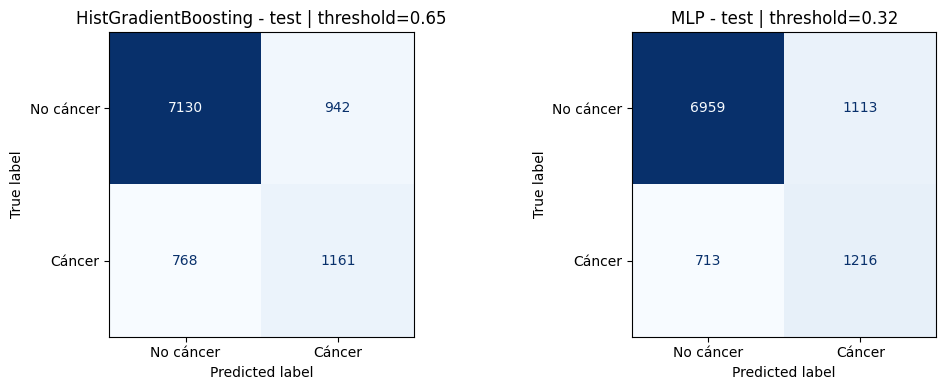

In [12]:
# Fase 6 - Evaluación final en test
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

def calcular_metricas(nombre, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "modelo": nombre,
        "threshold": threshold,
        "precision_cancer_1": precision_score(y_true, y_pred, zero_division=0),
        "recall_cancer_1": recall_score(y_true, y_pred, zero_division=0),
        "f1_cancer_1": f1_score(y_true, y_pred, zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
    }

# Mejor modelo ML baseline en test
y_test_proba_ml = probabilidades_clase_positiva(mejor_modelo_ml, X_test_prep)
threshold_ml = best_threshold_ml

# MLP en test usando el umbral elegido previamente en validación
X_test_mlp = X_test_prep.astype("float32")
y_test_proba_mlp = mlp_model.predict(X_test_mlp).ravel()

metricas_finales = pd.DataFrame(
    [
        calcular_metricas(mejor_modelo_ml_nombre, y_test, y_test_proba_ml, threshold_ml),
        calcular_metricas("MLP", y_test, y_test_proba_mlp, best_threshold_mlp),
    ]
)

metricas_finales = metricas_finales.sort_values(
    ["f1_cancer_1", "auc_roc"], ascending=False
).reset_index(drop=True)

display(
    metricas_finales.style.format(
        {
            "threshold": "{:.2f}",
            "precision_cancer_1": "{:.3f}",
            "recall_cancer_1": "{:.3f}",
            "f1_cancer_1": "{:.3f}",
            "auc_roc": "{:.3f}",
            "accuracy": "{:.3f}",
        }
    )
)

# Matrices de confusión
y_test_pred_ml = (y_test_proba_ml >= threshold_ml).astype(int)
y_test_pred_mlp = (y_test_proba_mlp >= best_threshold_mlp).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_test_pred_ml),
    display_labels=["No cáncer", "Cáncer"],
).plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title(f"{mejor_modelo_ml_nombre} - test | threshold={threshold_ml:.2f}")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_test_pred_mlp),
    display_labels=["No cáncer", "Cáncer"],
).plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title(f"MLP - test | threshold={best_threshold_mlp:.2f}")

plt.tight_layout()
plt.show()


## Interpretación de la evaluación final

- El modelo con mayor F1 ofrece el mejor equilibrio entre precisión y recall para `cancer = 1` bajo el criterio elegido.
- Al optimizar ambos umbrales en validación, `HistGradientBoosting` supera a la MLP en F1 y AUC-ROC.
- La MLP conserva mayor recall, por lo que podría interesar si el objetivo clínico fuera detectar más casos positivos aceptando más falsas alarmas.
- Para una recomendación general del proyecto, el baseline clásico es preferible: consigue mejor F1, mejor AUC, mayor precisión y menor complejidad.
- La decisión clínica no debe basarse solo en F1: si el sistema se usara para cribado, habría que definir antes si se prioriza recall, coste esperado, net benefit o reducción de falsos positivos.


# Fase 7 - Comparación global ML vs MLP

En esta fase se comparan todos los resultados para tomar una decisión de viabilidad. La comparación no debe basarse solo en una métrica: hay que mirar F1, recall, precisión, AUC-ROC, complejidad del modelo e interpretabilidad.

La comparación final utiliza los umbrales elegidos en validación para ambos modelos. Esto evita favorecer a un modelo por haber ajustado su punto de corte mientras el otro mantiene el umbral estándar `0.50`.

| Aspecto | Qué se analiza |
|---|---|
| Ranking final | Orden de modelos según F1 y AUC-ROC con umbrales optimizados |
| Barras de métricas | Comparación visual de precisión, recall, F1 y AUC |
| Curvas ROC | Capacidad de separación global, independiente del umbral |
| Espacio precisión-recall | Tradeoff clínico entre falsos positivos y falsos negativos |
| Viabilidad | Si el sistema es útil como apoyo, cribado o priorización |


,modelo,threshold,precision_cancer_1,recall_cancer_1,f1_cancer_1,auc_roc,accuracy
0,HistGradientBoosting,0.65,0.552,0.602,0.576,0.843,0.829
1,MLP,0.32,0.522,0.630,0.571,0.840,0.817


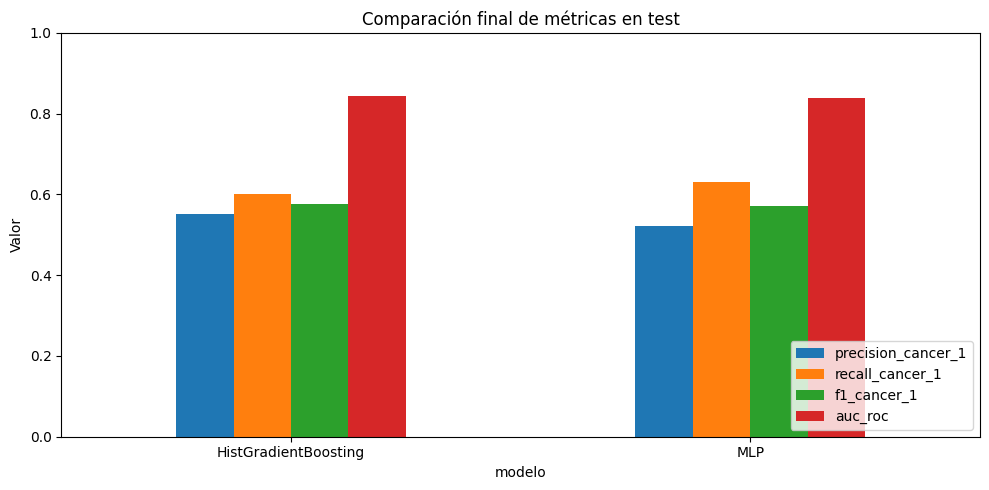

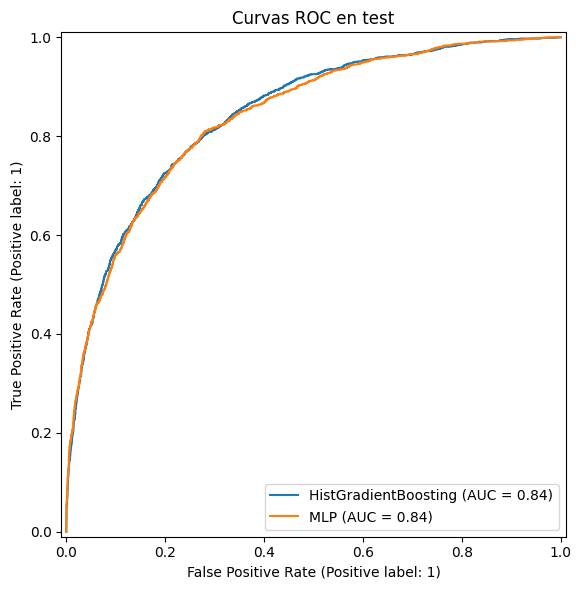

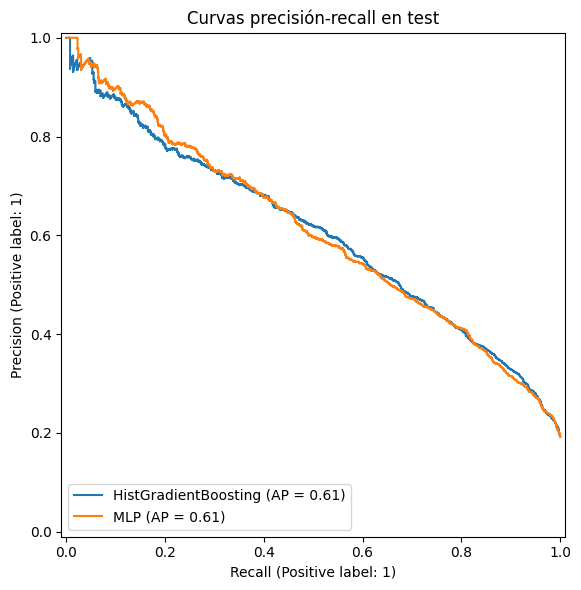

Modelo ganador según F1 en test con umbrales optimizados: HistGradientBoosting


In [14]:
# Fase 7 - Comparación global ML vs MLP
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# Ranking final según F1 y AUC-ROC
ranking_final = metricas_finales.sort_values(
    ["f1_cancer_1", "auc_roc"], ascending=False
).reset_index(drop=True)

display(
    ranking_final.style.format(
        {
            "threshold": "{:.2f}",
            "precision_cancer_1": "{:.3f}",
            "recall_cancer_1": "{:.3f}",
            "f1_cancer_1": "{:.3f}",
            "auc_roc": "{:.3f}",
            "accuracy": "{:.3f}",
        }
    )
)

# Gráfico de barras comparativo
metricas_plot = ranking_final.set_index("modelo")[
    ["precision_cancer_1", "recall_cancer_1", "f1_cancer_1", "auc_roc"]
]

ax = metricas_plot.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_title("Comparación final de métricas en test")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba_ml,
    name=mejor_modelo_ml_nombre,
    ax=ax,
)
RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba_mlp,
    name="MLP",
    ax=ax,
)
ax.set_title("Curvas ROC en test")
plt.tight_layout()
plt.show()

# Curvas Precision-Recall superpuestas
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba_ml,
    name=mejor_modelo_ml_nombre,
    ax=ax,
)
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba_mlp,
    name="MLP",
    ax=ax,
)
ax.set_title("Curvas precisión-recall en test")
plt.tight_layout()
plt.show()

modelo_ganador = ranking_final.loc[0, "modelo"]
print(f"Modelo ganador según F1 en test con umbrales optimizados: {modelo_ganador}")


## Conclusión técnica de viabilidad

La decisión final debe priorizar el equilibrio entre F1, recall y AUC-ROC, no la accuracy. En un problema de cáncer, el recall es especialmente importante porque un falso negativo puede tener un coste clínico alto. Aun así, una precisión demasiado baja generaría demasiadas falsas alarmas y podría saturar el sistema sanitario.

Tras optimizar el umbral de decisión de ambos modelos en validación, la recomendación técnica principal pasa a ser `HistGradientBoosting`. El modelo clásico obtiene mejor F1 y AUC-ROC en test, con mayor precisión que la MLP y una complejidad menor. La ventaja en F1 es pequeña, por lo que no debe presentarse como una superioridad amplia, sino como una recomendación pragmática por rendimiento, simplicidad e interpretabilidad.

La MLP no queda descartada: mantiene mayor recall y en la evaluación clínica muestra mejor calibración de probabilidades. Podría ser útil si el objetivo clínico fuera maximizar detección de casos positivos o informar probabilidades de riesgo, aunque esa ventaja implica más falsos positivos y exigiría validar/calibrar bien el sistema antes de usarlo.

Con F1 moderado, el sistema no debería utilizarse como diagnóstico automático. Su uso viable sería como herramienta de apoyo: priorización de pacientes, selección para revisión clínica adicional o ayuda al cribado.

Limitaciones principales:

- Dataset sintético y posible diferencia con pacientes reales.
- Ruido y solapamiento entre pacientes con y sin cáncer.
- Variables genéticas y socioeconómicas requieren justificación ética y disponibilidad previa.
- El modelo necesita validación externa antes de cualquier uso clínico.
- El umbral óptimo puede cambiar si cambia la prevalencia, el coste de falsos negativos o la capacidad asistencial disponible.

Datos adicionales que podrían mejorar la predicción: antecedentes familiares, resultados de imagen médica, marcadores tumorales específicos, evolución temporal de analíticas, síntomas registrados y validación con cohortes reales.
